In [1]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
import capillary_wave_analysis as cwa
import PSD_utils
from scipy.signal import welch

In [2]:
plt.rc("axes.spines", right=True, top=True)
plt.rc("font", family="serif")
plt.rc("legend", edgecolor="none", frameon=False)

log2_xticks = np.array([4, 8, 16, 32, 64], dtype=float)    # x ticks for log2 scale

import warnings
warnings.filterwarnings("ignore")

In [11]:
# Load all 1D data for 0.30vpp datasets (10 sets)

power = '0p10'

base = f"/disk/hyk049/DHM_new_1Dcenter/{power}/"

def h5read_T(fname, dset):
    with h5py.File(fname, "r") as f:
        return np.array(f[dset])

t = h5read_T(base + f"Q_1D_{power}vpp_a.h5", "/t")
x = h5read_T(base + f"Q_1D_{power}vpp_a.h5", "/x")
nx = len(x)

labels = list("bcdefhijk")
# labels = list("l") # 0p04

# labels = list("bcdg")
# labels = list("aefhij") # 0p08

# Load all Q matrices
Q = {}
for lbl in labels:
    fname = f"{base}Q_1D_{power}vpp_{lbl}.h5"
    Q[lbl] = h5read_T(fname, "/Q_1D")

dt = t[1] - t[0]
t_dep = 0.05
seg_len = int(t_dep//dt)+1
num_segs = len(t)//seg_len

Q_a = Q["b"]
nx, nt = Q_a.shape
t_new = seg_len * num_segs

Q_a_split = np.split(Q_a[:,:t_new], num_segs, axis=1)

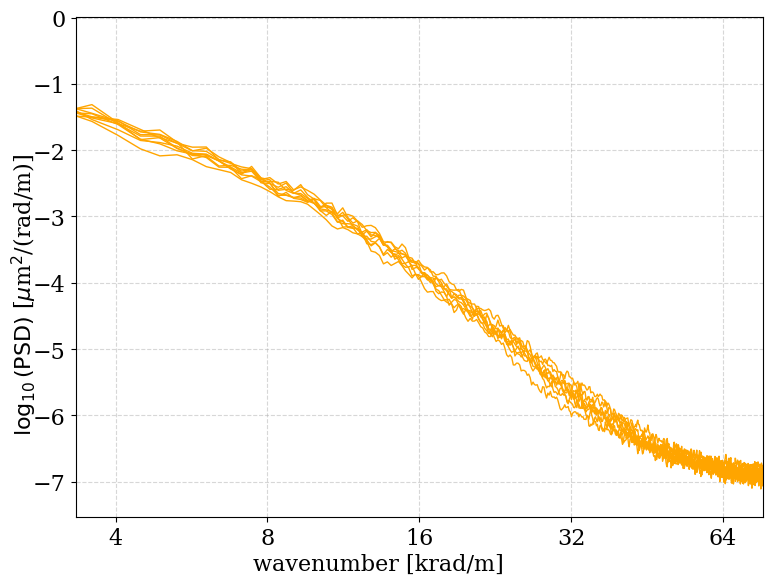

In [13]:
FS_DHM = 115_200
i_center = 100

target_segments = 100

labels = list(Q.keys())

fig, ax = plt.subplots(figsize=(8, 6))
for idx, lbl in enumerate(labels):
    Q_mat = Q[lbl]

    if idx == 0:
        Q_avg = Q_mat
    else:
        Q_avg = (Q_avg + Q_mat)/2
    
    # Full PSD
    k_exp, psd_exp, *_ = PSD_utils.compute_PSD(Q_mat[i_center,:], FS_DHM, 5, target_segments)
    ax.plot(k_exp, psd_exp, color='orange', lw=1.0)
    
    ax.set_xscale('log', base=2)
    ax.set_xlim(log2_xticks.min()/1.2, log2_xticks.max()*1.2)
    ax.grid(True, which='both', ls='--', alpha=0.5)

ax.set_xticks(log2_xticks)
ax.set_xticklabels([str(int(x)) for x in log2_xticks], fontsize=16)
ax.tick_params(axis='y', labelsize=16)
fig.text(0.5, 0.04, "wavenumber [krad/m]", ha='center', fontsize=16)
fig.text(0.04, 0.5, r"$\log_{10}(\mathrm{PSD})$ [$\mu$m$^2$/(rad/m)]", va='center', rotation='vertical', fontsize=16)
plt.tight_layout(rect=[0.05, 0.05, 1, 1])
plt.legend()
plt.show()


In [54]:
import glob
import os

powers = ['0p0', '0p04', '0p07', '0p08', '0p10', '0p15', '0p18', '0p20', '0p25', '0p30', '0p35']

def h5read_T(fname, dset):
    with h5py.File(fname, "r") as f:
        return np.array(f[dset])

def get_prefix_and_labels(power):
    """Return (base_dir, file_prefix, single_letter_labels) for a given power."""
    base = f"/disk/hyk049/DHM_new_1Dcenter/{power}/"
    prefix = "Q_1D_0vpp" if power == '0p0' else f"Q_1D_{power}vpp"
    # Only single-letter labels (skip transition files like k_to_kl)
    files = sorted(glob.glob(os.path.join(base, f"{prefix}_?.h5")))
    labels = [os.path.basename(f)[len(prefix)+1:-3] for f in files]
    return base, prefix, labels

FS_DHM = 115_200
i_center = 100
target_segments = 100

all_psds = {}   # power -> list of (k_exp, psd_exp)

for power in powers:
    base, prefix, labels = get_prefix_and_labels(power)
    print(f"Power {power}: {len(labels)} datasets {labels}")

    t = h5read_T(base + f"{prefix}_a.h5", "/t")
    dt = t[1] - t[0]

    psds = []
    for lbl in labels:
        fname = f"{base}{prefix}_{lbl}.h5"
        Q_mat = h5read_T(fname, "/Q_1D")
        k_exp, psd_exp, *_ = PSD_utils.compute_PSD(Q_mat[i_center, :], FS_DHM, 5, target_segments)
        psds.append((k_exp, psd_exp))

    all_psds[power] = psds
    print(f"  -> {len(psds)} PSDs computed")


Power 0p0: 10 datasets ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j']


Power 0p0: 10 datasets ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j']


  -> 10 PSDs computed
Power 0p04: 14 datasets ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n']
  -> 14 PSDs computed
Power 0p07: 16 datasets ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p']
  -> 16 PSDs computed
Power 0p08: 10 datasets ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j']
  -> 10 PSDs computed
Power 0p10: 16 datasets ['a', 'b', 'c', 'd', 'e', 'f', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q']
  -> 16 PSDs computed
Power 0p15: 10 datasets ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j']
  -> 10 PSDs computed
Power 0p18: 10 datasets ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j']
  -> 10 PSDs computed
Power 0p20: 14 datasets ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n']
  -> 14 PSDs computed
Power 0p25: 10 datasets ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j']
  -> 10 PSDs computed
Power 0p30: 14 datasets ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n']
  -> 14

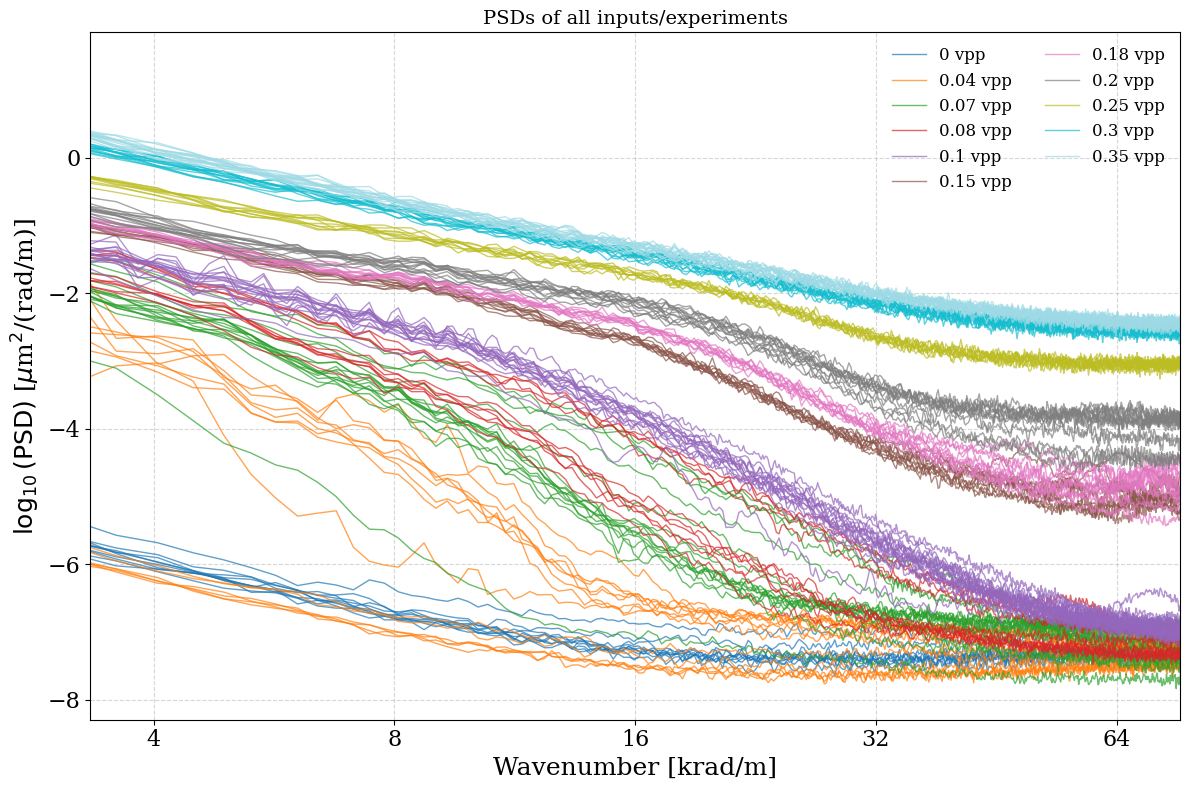

In [66]:
fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.tab20(np.linspace(0, 1, len(powers)))

for i, power in enumerate(powers):
    color = colors[i]
    label_str = power.replace('p', '.').rstrip('0').rstrip('.')

    for j, (k_exp, psd_exp) in enumerate(all_psds[power]):
        ax.plot(
            k_exp, psd_exp,
            color=color, lw=1.0, alpha=0.7,
            label=f'{label_str} vpp' if j == 0 else None,
        )

ax.set_xscale('log', base=2)
ax.set_xlim(log2_xticks.min() / 1.2, log2_xticks.max() * 1.2)
ax.set_xticks(log2_xticks)
ax.set_xticklabels([str(int(v)) for v in log2_xticks], fontsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.grid(True, which='both', ls='--', alpha=0.5)
ax.set_xlabel('Wavenumber [krad/m]', fontsize=18)
ax.set_ylabel(r'$\log_{10}(\mathrm{PSD})$ [$\mu$m$^2$/(rad/m)]', fontsize=18)
ax.legend(ncol=2, fontsize=12)
ax.set_title('PSDs of all inputs/experiments', fontsize=14)

plt.tight_layout()
plt.show()


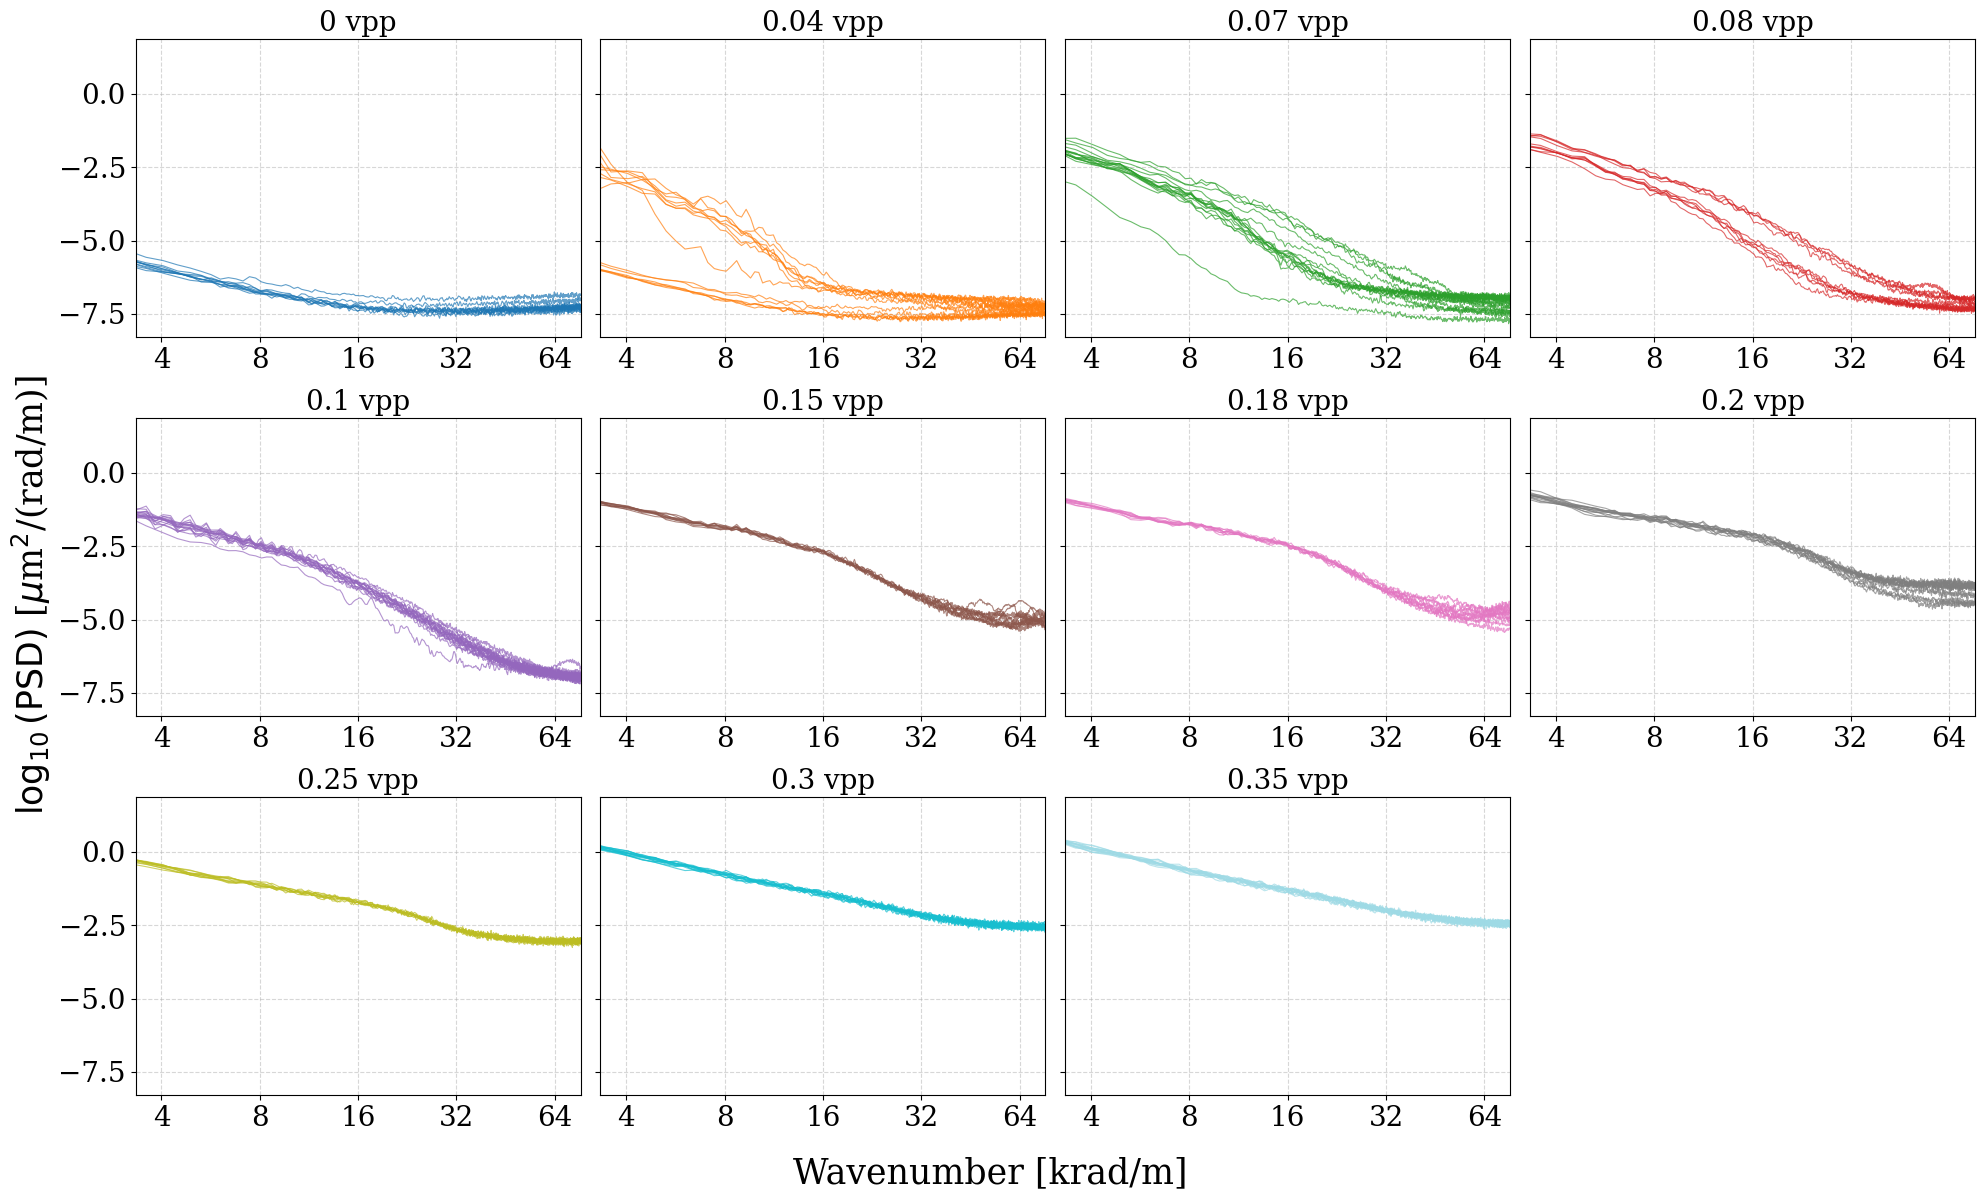

In [70]:
n_powers = len(powers)          # 11
ncols = 4
nrows = -(-n_powers // ncols)   # ceil division → 3 rows × 4 cols = 12 slots

colors = plt.cm.tab20(np.linspace(0, 1, len(powers)))

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows), sharex=False, sharey=True)
axes_flat = axes.flatten()

for i, power in enumerate(powers):
    ax = axes_flat[i]
    color = colors[i]
    for k_exp, psd_exp in all_psds[power]:
        ax.plot(k_exp, psd_exp, color=color, lw=0.8, alpha=0.7)

    ax.set_xscale('log', base=2)
    ax.set_xlim(log2_xticks.min() / 1.2, log2_xticks.max() * 1.2)
    ax.set_xticks(log2_xticks)
    ax.set_xticklabels([str(int(v)) for v in log2_xticks], fontsize=20)
    ax.tick_params(axis='y', labelsize=20)
    ax.grid(True, which='both', ls='--', alpha=0.5)
    label_str = power.replace('p', '.').rstrip('0').rstrip('.')
    ax.set_title(f"{label_str} vpp", fontsize=20)

# Hide unused subplots
for j in range(n_powers, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.text(0.5, 0.01, "Wavenumber [krad/m]", ha='center', fontsize=25)
fig.text(0.01, 0.5, r"$\log_{10}(\mathrm{PSD})$ [$\mu$m$^2$/(rad/m)]", va='center', rotation='vertical', fontsize=25)

plt.tight_layout(rect=[0.04, 0.04, 1, 1])
plt.show()


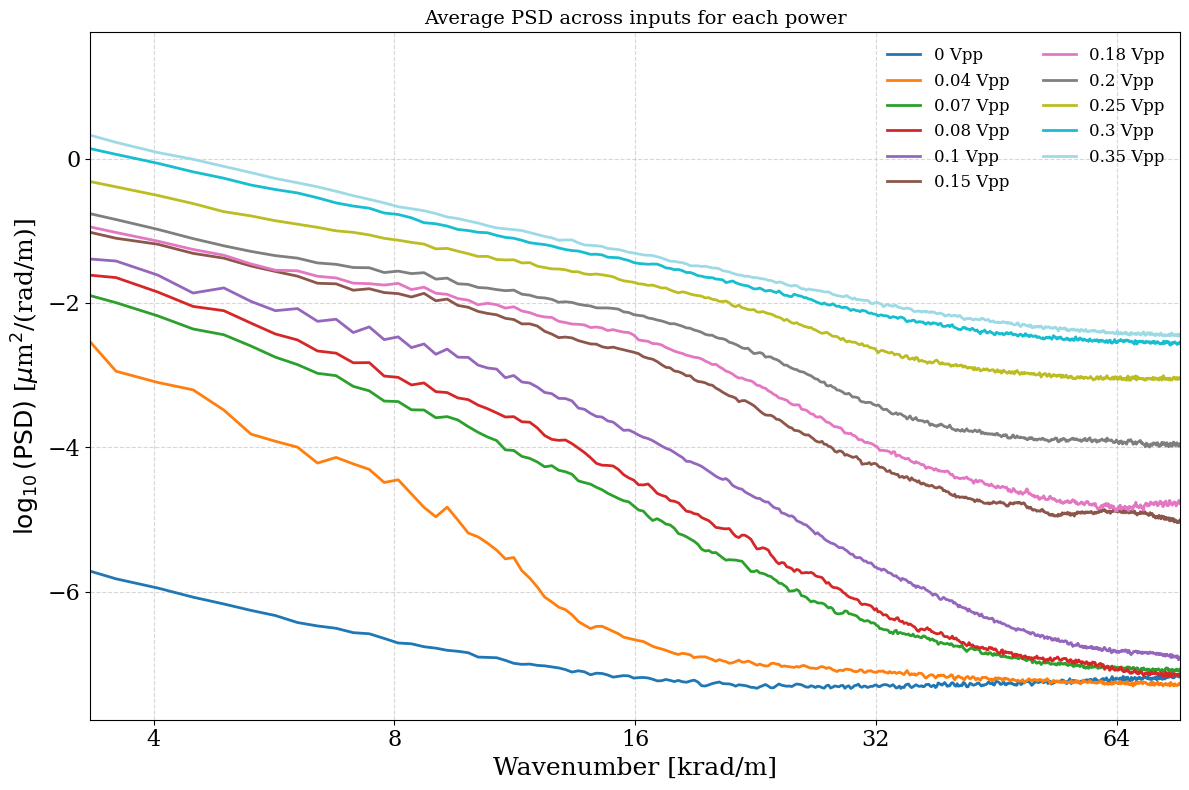

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.tab20(np.linspace(0, 1, len(powers)))

avg_psd_from_cell6 = {}

for i, power in enumerate(powers):
    k_ref = all_psds[power][0][0]
    psd_linear_stack = []

    for k_exp, psd_exp in all_psds[power]:
        psd_linear = 10**psd_exp
        if not np.array_equal(k_exp, k_ref):
            psd_linear = np.interp(k_ref, k_exp, psd_linear)
        psd_linear_stack.append(psd_linear)

    psd_linear_mean = np.mean(np.vstack(psd_linear_stack), axis=0)
    psd_log_mean = np.log10(np.maximum(psd_linear_mean, np.finfo(float).tiny))
    avg_psd_from_cell6[power] = (k_ref, psd_log_mean)

    label_str = power.replace('p', '.').rstrip('0').rstrip('.')
    ax.plot(k_ref, psd_log_mean, color=colors[i], lw=2.0, label=f'{label_str} vpp')

ax.set_xscale('log', base=2)
ax.set_xlim(log2_xticks.min() / 1.2, log2_xticks.max() * 1.2)
ax.set_xticks(log2_xticks)
ax.set_xticklabels([str(int(v)) for v in log2_xticks], fontsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.grid(True, which='both', ls='--', alpha=0.5)
ax.set_xlabel('Wavenumber [krad/m]', fontsize=18)
ax.set_ylabel(r'$\log_{10}(\mathrm{PSD})$ [$\mu$m$^2$/(rad/m)]', fontsize=18)
ax.legend(ncol=2, fontsize=12)
ax.set_title('Average PSD across inputs for each power', fontsize=14)

plt.tight_layout()
plt.show()

In [40]:
powers = ['0p0', '0p04', '0p07', '0p08', '0p10', '0p15', '0p18', '0p20', '0p25', '0p30', '0p35']

def h5read_T(fname, dset):
    with h5py.File(fname, "r") as f:
        return np.array(f[dset])

def get_prefix_and_labels(power):
    """Return (base_dir, file_prefix, single_letter_labels) for a given power."""
    base = f"/disk/hyk049/DHM_new_1Dcenter/{power}/"
    prefix = "Q_1D_0vpp" if power == '0p0' else f"Q_1D_{power}vpp"
    # Only single-letter labels (skip transition files like k_to_kl)
    files = sorted(glob.glob(os.path.join(base, f"{prefix}_?.h5")))
    labels = [os.path.basename(f)[len(prefix)+1:-3] for f in files]
    return base, prefix, labels

FS_DHM = 115_200
i_center = 100
target_segments = 100

PSDs_avgs = {}   # power -> list of (k_exp, psd_exp)

for power in powers:
    base, prefix, labels = get_prefix_and_labels(power)
    print(f"Power {power}: {len(labels)} datasets {labels}")

    t = h5read_T(base + f"{prefix}_a.h5", "/t")
    dt = t[1] - t[0]

    Q_stack_all = []
    for lbl in labels:
        fname = f"{base}{prefix}_{lbl}.h5"
        Q_mat = h5read_T(fname, "/Q_1D")
        
        nx, nt = Q_mat.shape
        t_new = seg_len * num_segs
        Q_split = np.split(Q_mat[:, :t_new], num_segs, axis=1)
        Q_stack = np.stack(Q_split, axis=1)
        
        Q_stack_all.append(Q_stack)

    Q_stack_all = np.stack(Q_stack_all, axis=1)
    Q_stack_all = Q_stack_all.reshape(nx, len(labels)*num_segs, seg_len)

    Q_subspace = np.mean(Q_stack_all, axis=1)
    
    k_all, psd_all, f_all, *_ = \
        PSD_utils.compute_PSD(Q_subspace[i_center, :], FS_DHM, 5, 30)

    PSDs_avgs[power] = (k_all, psd_all, f_all)
    print(f"  -> {len(labels)} datasets averaged, PSD computed")


Power 0p0: 10 datasets ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j']
  -> 10 datasets averaged, PSD computed
Power 0p04: 14 datasets ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n']
  -> 14 datasets averaged, PSD computed
Power 0p07: 16 datasets ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p']
  -> 16 datasets averaged, PSD computed
Power 0p08: 10 datasets ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j']
  -> 10 datasets averaged, PSD computed
Power 0p10: 16 datasets ['a', 'b', 'c', 'd', 'e', 'f', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q']
  -> 16 datasets averaged, PSD computed
Power 0p15: 10 datasets ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j']
  -> 10 datasets averaged, PSD computed
Power 0p18: 10 datasets ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j']
  -> 10 datasets averaged, PSD computed
Power 0p20: 14 datasets ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n']
  -> 14 datasets aver

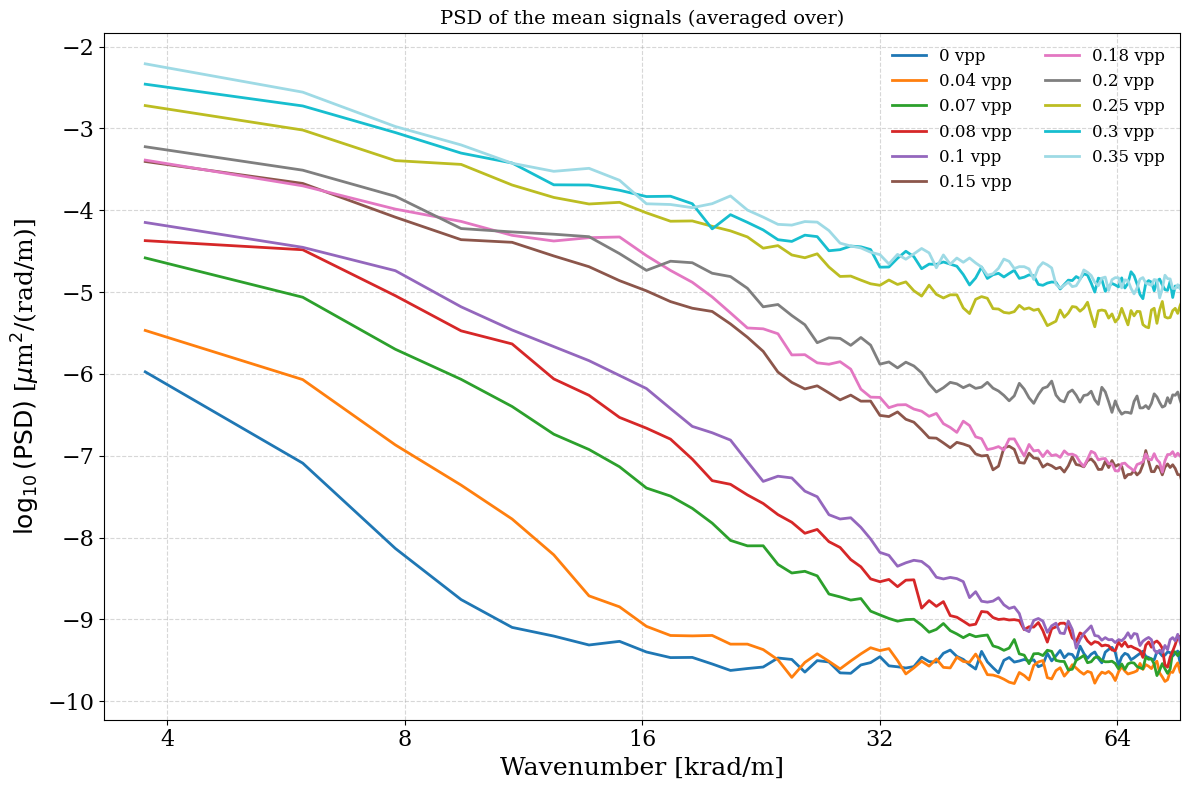

In [77]:
fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.tab20(np.linspace(0, 1, len(powers)))

for i, power in enumerate(powers):
    k_krad, log10_psd, _ = PSDs_avgs[power]
    label_str = power.replace('p', '.').rstrip('0').rstrip('.')
    ax.plot(k_krad, log10_psd, color=colors[i], lw=2.0, label=f'{label_str} vpp')

ax.set_xscale('log', base=2)
ax.set_xlim(log2_xticks.min() / 1.2, log2_xticks.max() * 1.2)
ax.set_xticks(log2_xticks)
ax.set_xticklabels([str(int(v)) for v in log2_xticks], fontsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.grid(True, which='both', ls='--', alpha=0.5)
ax.set_xlabel('Wavenumber [krad/m]', fontsize=18)
ax.set_ylabel(r'$\log_{10}(\mathrm{PSD})$ [$\mu$m$^2$/(rad/m)]', fontsize=18)
ax.legend(ncol=2, fontsize=12)
ax.set_title('PSD of the mean signals (averaged over)', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
from scipy.io import loadmat

amp = 1
ROM_form = 'ABN'


powers = ['0p04', '0p07', '0p08', '0p10', '0p15', '0p18', '0p20', '0p25', '0p30', '0p35']
r_all = [13, 11, 10, 12, 13, 5, 11, 13, 19, 14]
sig_all = [40, 7, 30, 37, 31, 29, 31, 10, 6, 5]

psd_FOM_all = []
psd_ROM_all = []
i_center = 100

for rr, sig, power in zip(r_all, sig_all, powers):
    file_path = f'/disk/hyk049/WT_RomFit/{power}/'
    filename = f"{file_path}{power}vpp_r={rr}_{ROM_form}_amp{amp}_sigma{sig}_new.mat"
    
    data = loadmat(filename)
    EFOM = data['EFOM']
    EROM = data['EROM_opt']
    
    k_FOM, psd_FOM, f_FOM, *_ = PSD_utils.compute_PSD(EFOM[i_center,:], FS_DHM, 5, 30)
    k_ROM, psd_ROM, f_ROM, *_ = PSD_utils.compute_PSD(EROM[i_center,:], FS_DHM, 5, 30)
    
    psd_FOM_all.append(psd_FOM)
    psd_ROM_all.append(psd_ROM)

/disk/hyk049/WT_RomFit/0p04/0p04vpp_r=13_ABN_amp1_sigma40_new.mat
/disk/hyk049/WT_RomFit/0p07/0p07vpp_r=11_ABN_amp1_sigma7_new.mat
/disk/hyk049/WT_RomFit/0p08/0p08vpp_r=10_ABN_amp1_sigma30_new.mat
/disk/hyk049/WT_RomFit/0p10/0p10vpp_r=12_ABN_amp1_sigma37_new.mat
/disk/hyk049/WT_RomFit/0p15/0p15vpp_r=13_ABN_amp1_sigma31_new.mat
/disk/hyk049/WT_RomFit/0p18/0p18vpp_r=5_ABN_amp1_sigma29_new.mat
/disk/hyk049/WT_RomFit/0p20/0p20vpp_r=11_ABN_amp1_sigma31_new.mat
/disk/hyk049/WT_RomFit/0p25/0p25vpp_r=13_ABN_amp1_sigma10_new.mat
/disk/hyk049/WT_RomFit/0p30/0p30vpp_r=19_ABN_amp1_sigma6_new.mat
/disk/hyk049/WT_RomFit/0p35/0p35vpp_r=14_ABN_amp1_sigma5_new.mat


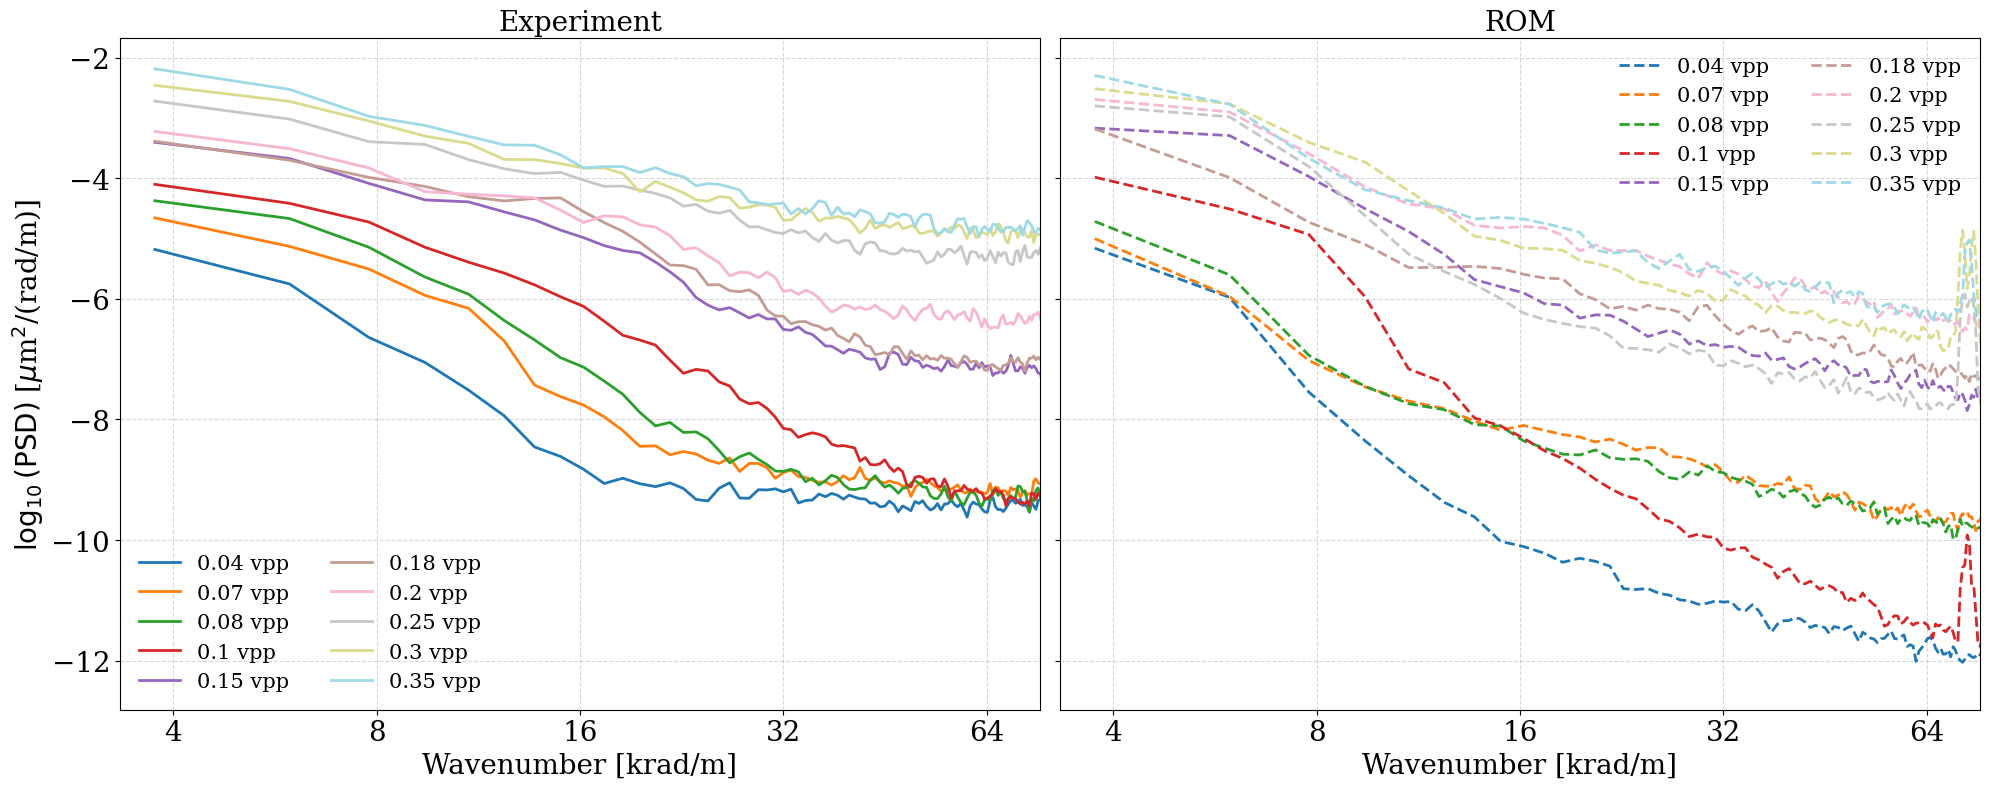

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)
ax_FOM, ax_ROM = axes

colors = plt.cm.tab20(np.linspace(0, 1, len(powers)))

for i, (power, psd_FOM, psd_ROM) in enumerate(zip(powers, psd_FOM_all, psd_ROM_all)):
    label_str = power.replace('p', '.').rstrip('0').rstrip('.')
    
    ax_FOM.plot(k_FOM, psd_FOM, color=colors[i], lw=2, alpha=1, label=f'{label_str} vpp')
    ax_ROM.plot(k_ROM, psd_ROM, color=colors[i], ls = '--', lw=2, alpha=1, label=f'{label_str} vpp')

for ax in axes:
    ax.set_xscale('log', base=2)
    ax.set_xlim(log2_xticks.min() / 1.2, log2_xticks.max() * 1.2)
    ax.set_xticks(log2_xticks)
    ax.set_xticklabels([str(int(v)) for v in log2_xticks], fontsize=20)
    ax.tick_params(axis='y', labelsize=20)
    ax.grid(True, which='both', ls='--', alpha=0.5)
    ax.set_xlabel('Wavenumber [krad/m]', fontsize=20)

ax_FOM.set_ylabel(r'$\log_{10}(\mathrm{PSD})$ [$\mu$m$^2$/(rad/m)]', fontsize=20)
ax_FOM.set_title('Experiment', fontsize=20)
ax_ROM.set_title('ROM', fontsize=20)
ax_FOM.legend(ncol=2, fontsize=15)
ax_ROM.legend(ncol=2, fontsize=15)

plt.tight_layout()
plt.show()

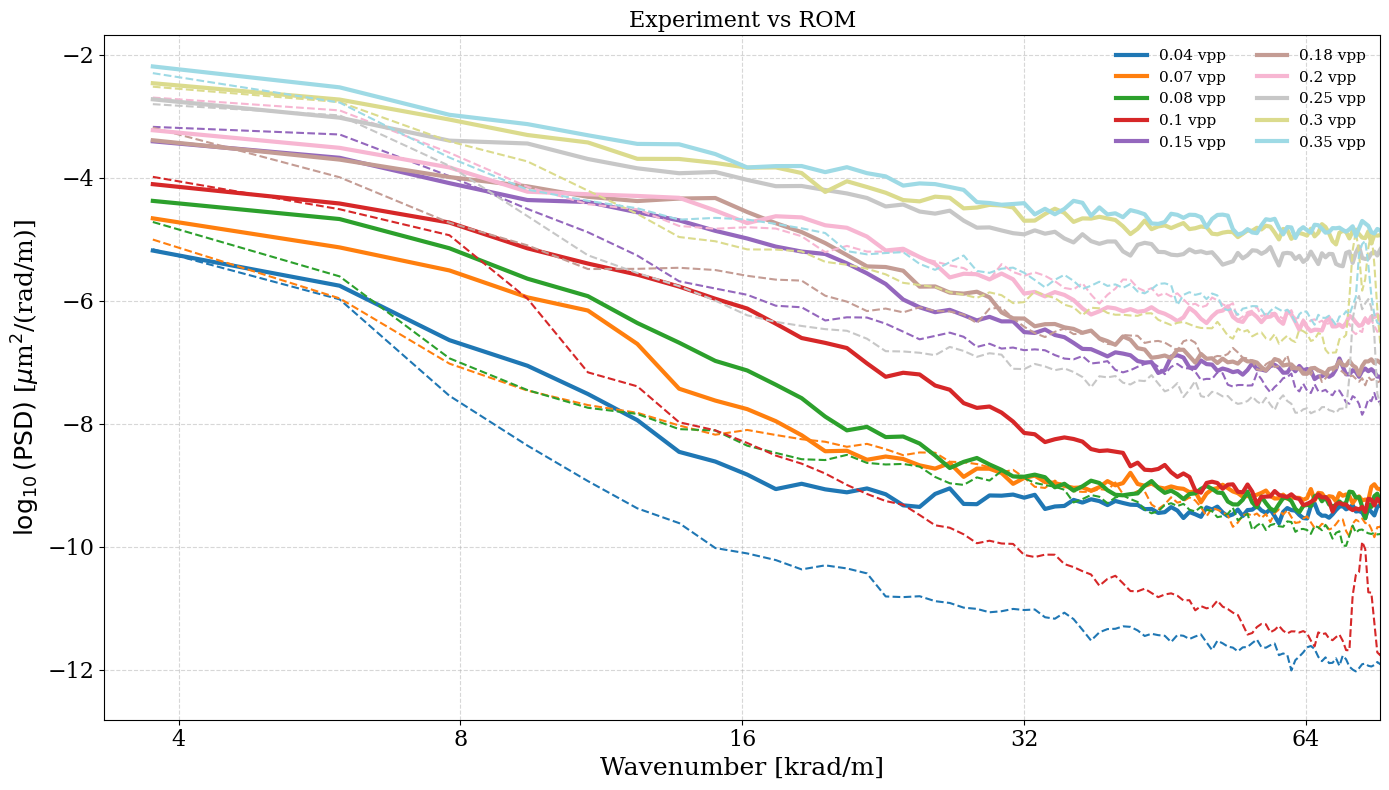

In [118]:
fig, ax = plt.subplots(figsize=(14, 8))

colors = plt.cm.tab20(np.linspace(0, 1, len(powers)))

for i, (power, psd_FOM, psd_ROM) in enumerate(zip(powers, psd_FOM_all, psd_ROM_all)):
    label_str = power.replace('p', '.').rstrip('0').rstrip('.')
    
    # FOM as bold solid line
    ax.plot(k_FOM, psd_FOM, color=colors[i], lw=3.0, linestyle='-', 
            label=f'{label_str} vpp')
    # ROM as dashed line
    ax.plot(k_ROM, psd_ROM, color=colors[i], lw=1.5, linestyle='--')

ax.set_xscale('log', base=2)
ax.set_xlim(log2_xticks.min() / 1.2, log2_xticks.max() * 1.2)
ax.set_xticks(log2_xticks)
ax.set_xticklabels([str(int(v)) for v in log2_xticks], fontsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.grid(True, which='both', ls='--', alpha=0.5)
ax.set_xlabel('Wavenumber [krad/m]', fontsize=18)
ax.set_ylabel(r'$\log_{10}(\mathrm{PSD})$ [$\mu$m$^2$/(rad/m)]', fontsize=18)
ax.set_title('Experiment vs ROM', fontsize=16)
ax.legend(ncol=2, fontsize=11, loc='best')

plt.tight_layout()
plt.show()

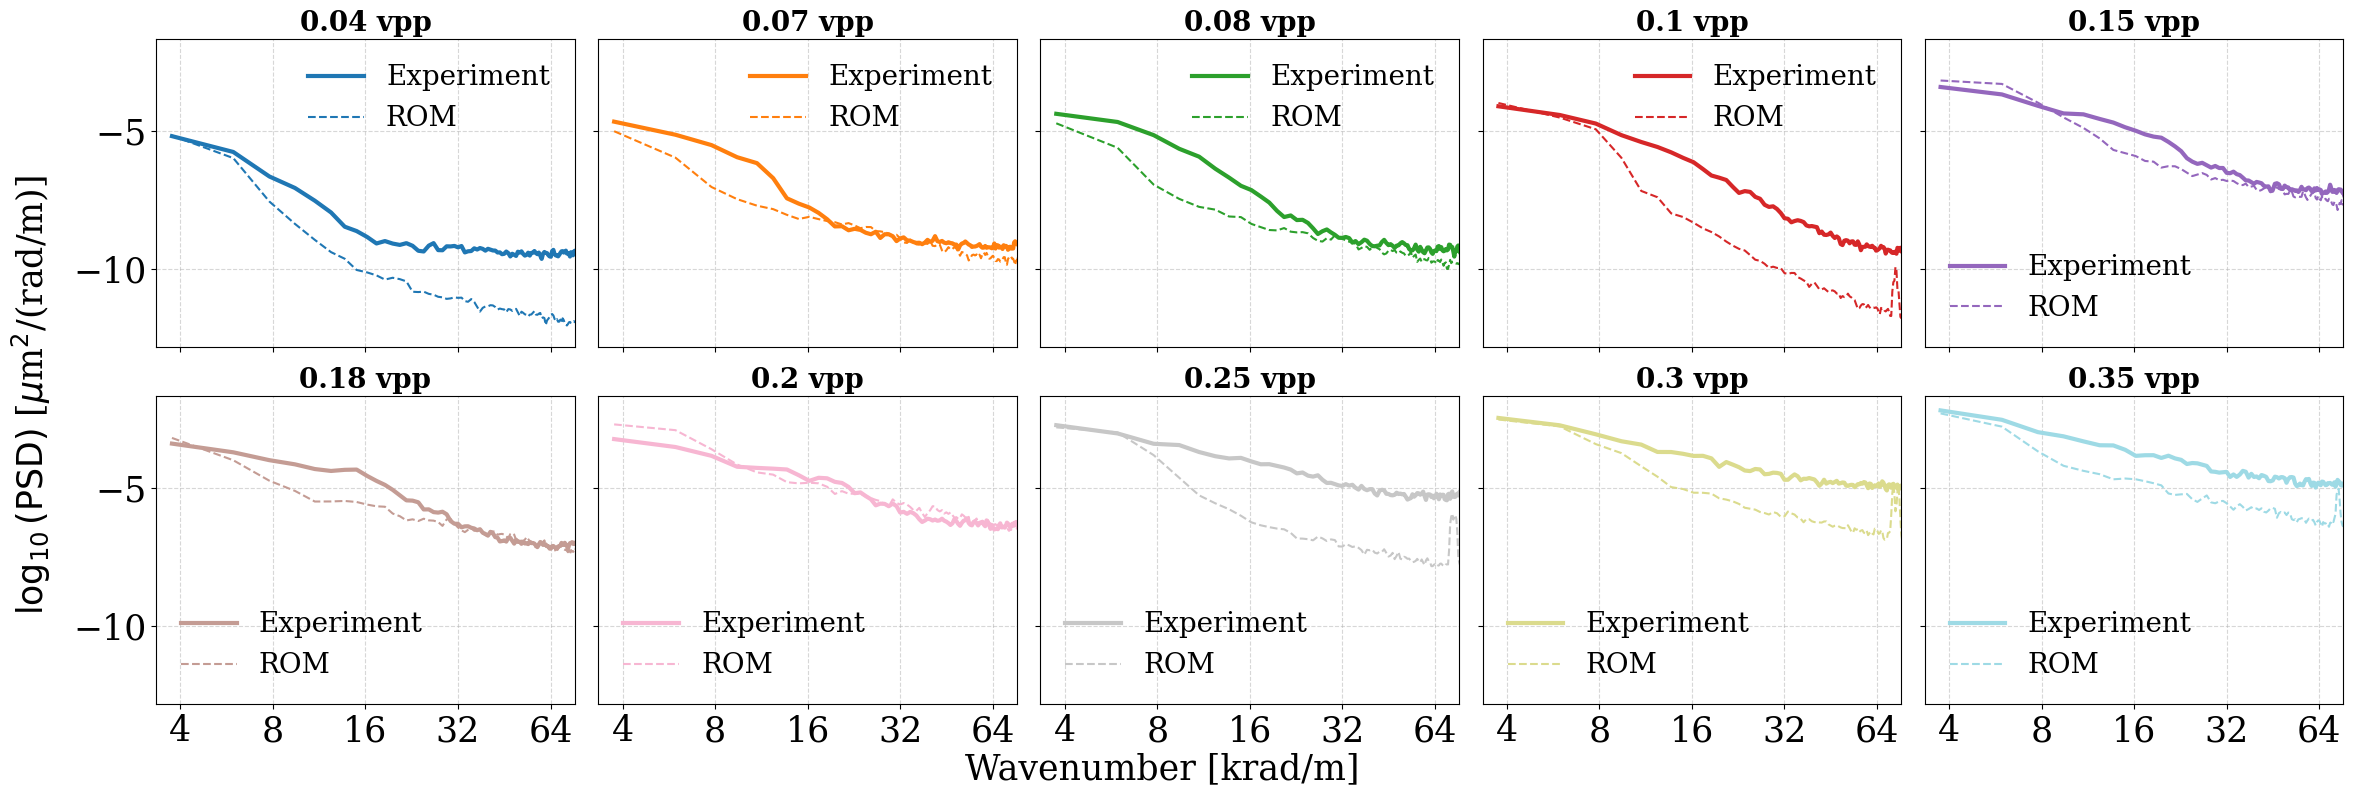

In [129]:
fig, axes = plt.subplots(2, 5, figsize=(24, 8), sharex=True, sharey=True)
axes_flat = axes.flatten()

colors = plt.cm.tab20(np.linspace(0, 1, len(powers)))

for i, (power, psd_FOM, psd_ROM) in enumerate(zip(powers, psd_FOM_all, psd_ROM_all)):
    ax = axes_flat[i]
    label_str = power.replace('p', '.').rstrip('0').rstrip('.')
    
    # FOM as bold solid line
    ax.plot(k_FOM, psd_FOM, color=colors[i], lw=3.0, linestyle='-', label=f'Experiment')
    # ROM as dashed line
    ax.plot(k_ROM, psd_ROM, color=colors[i], lw=1.5, linestyle='--', label=f'ROM')
    
    ax.set_xscale('log', base=2)
    ax.set_xlim(log2_xticks.min() / 1.2, log2_xticks.max() * 1.2)
    ax.set_xticks(log2_xticks)
    ax.set_xticklabels([str(int(v)) for v in log2_xticks], fontsize=25)
    ax.tick_params(axis='y', labelsize=25)
    ax.grid(True, which='both', ls='--', alpha=0.5)
    ax.set_title(f'{label_str} vpp', fontsize=20, fontweight='bold')
    ax.legend(fontsize=20, loc='best')

fig.text(0.5, 0.02, 'Wavenumber [krad/m]', ha='center', fontsize=25)
fig.text(0.02, 0.5, r'$\log_{10}(\mathrm{PSD})$ [$\mu$m$^2$/(rad/m)]', va='center', rotation='vertical', fontsize=25)

plt.tight_layout(rect=[0.04, 0.04, 1, 1])
plt.show()

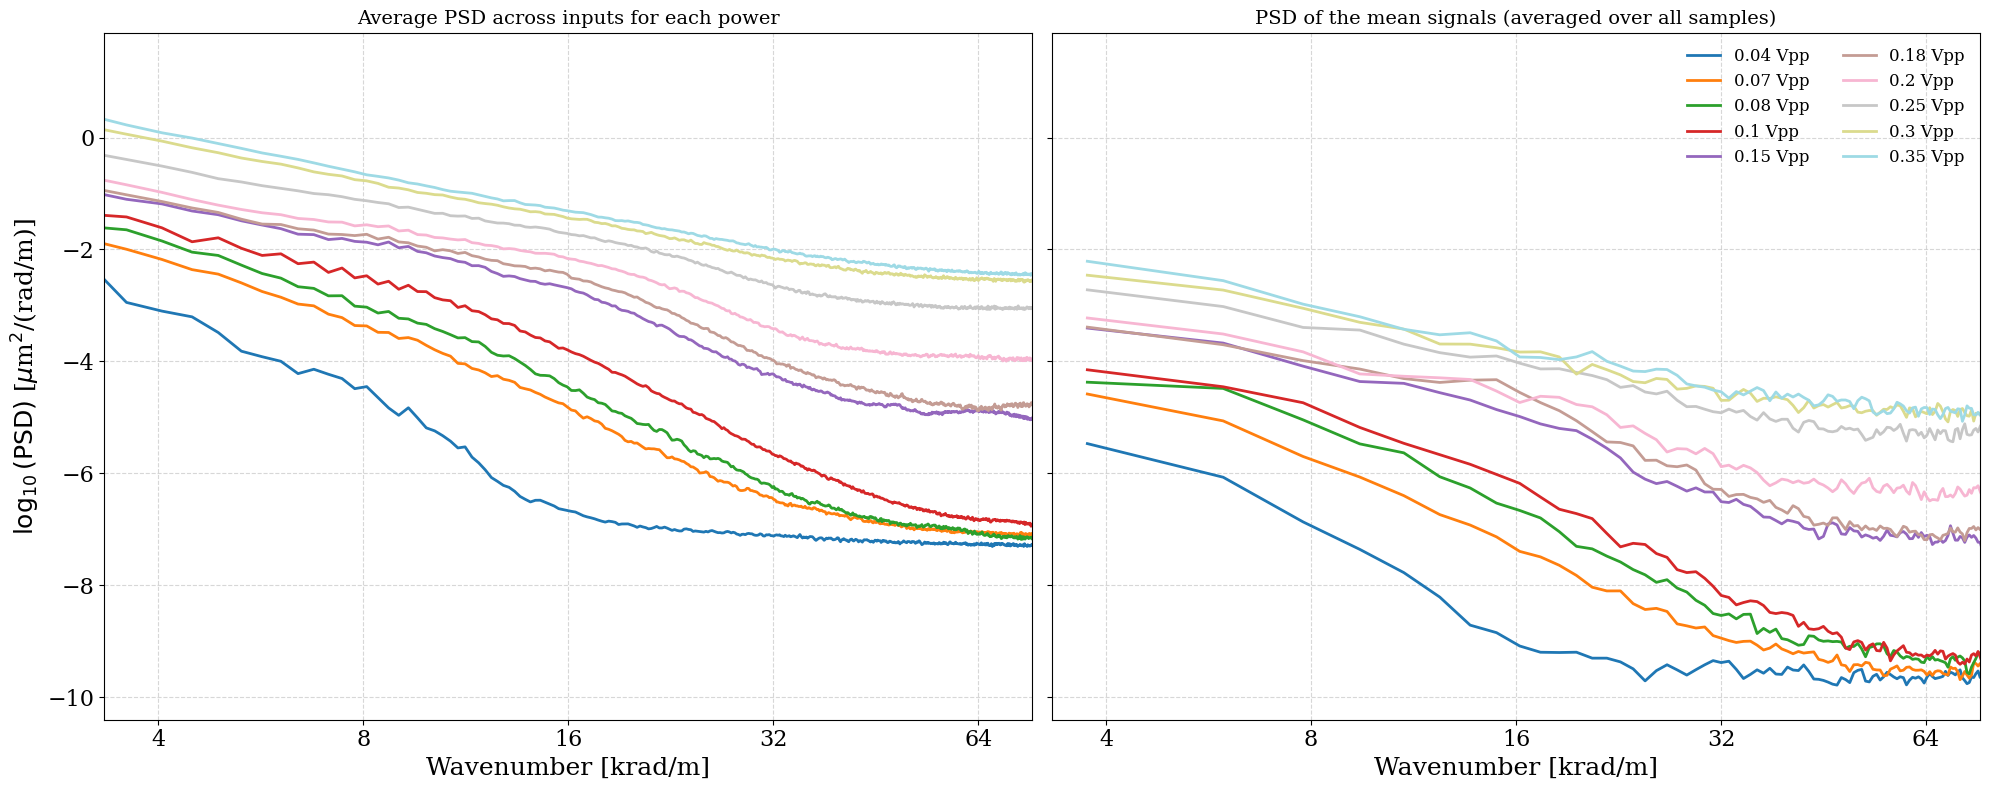

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)
ax1, ax2 = axes

colors = plt.cm.tab20(np.linspace(0, 1, len(powers)))

avg_psd_from_cell6 = {}

for i, power in enumerate(powers):
    k_ref = all_psds[power][0][0]
    psd_linear_stack = []

    for k_exp, psd_exp in all_psds[power]:
        psd_linear = 10**psd_exp
        if not np.array_equal(k_exp, k_ref):
            psd_linear = np.interp(k_ref, k_exp, psd_linear)
        psd_linear_stack.append(psd_linear)

    psd_linear_mean = np.mean(np.vstack(psd_linear_stack), axis=0)
    psd_log_mean = np.log10(np.maximum(psd_linear_mean, np.finfo(float).tiny))
    avg_psd_from_cell6[power] = (k_ref, psd_log_mean)

    label_str = power.replace('p', '.').rstrip('0').rstrip('.')
    ax1.plot(k_ref, psd_log_mean, color=colors[i], lw=2.0, label=f'{label_str} Vpp')

for i, power in enumerate(powers):
    k_krad, log10_psd, _ = PSDs_avgs[power]
    label_str = power.replace('p', '.').rstrip('0').rstrip('.')
    ax2.plot(k_krad, log10_psd, color=colors[i], lw=2.0, label=f'{label_str} Vpp')

for ax in axes:
    ax.set_xscale('log', base=2)
    ax.set_xlim(log2_xticks.min() / 1.2, log2_xticks.max() * 1.2)
    ax.set_xticks(log2_xticks)
    ax.set_xticklabels([str(int(v)) for v in log2_xticks], fontsize=16)
    ax.tick_params(axis='y', labelsize=16)
    ax.grid(True, which='both', ls='--', alpha=0.5)
    ax.set_xlabel('Wavenumber [krad/m]', fontsize=18)

ax1.set_ylabel(r'$\log_{10}(\mathrm{PSD})$ [$\mu$m$^2$/(rad/m)]', fontsize=18)
ax1.set_title('Average PSD across inputs for each power', fontsize=14)
ax2.set_title('PSD of the mean signals (averaged over all samples)', fontsize=14)
ax2.legend(ncol=2, fontsize=12)

plt.tight_layout()
plt.show()